# Interscale

## Setup

In [1]:
import scanpy as sc
import os
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse
import seaborn as sns
import random
import torch
from pathlib import Path
import scvi

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` in

In [2]:
def set_full_reproducibility(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False



set_full_reproducibility(42)

In [3]:
INTERSCALE_DIR = '/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/InterScale_reproducibility'
print(INTERSCALE_DIR)
os.chdir(INTERSCALE_DIR)

/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/InterScale_reproducibility


In [4]:
from joblib import load, dump

In [5]:
def aggregate_attention_matrix_optimized(attn_matrix, labels):
    labels = np.array(labels)
    unique_labels = np.unique(labels)
    try:
        unique_labels = sorted(unique_labels, key=lambda x: int(x))
    except:
        unique_labels = sorted(unique_labels)
    
    n_labels = len(unique_labels)
    aggregated = np.zeros((n_labels, n_labels))
    
    label_indices = {label: np.where(labels == label)[0] for label in unique_labels}
    

    for i, row_label in enumerate(unique_labels):
        row_idxs = label_indices[row_label]
        row_data = attn_matrix[row_idxs, :]
        
        for j, col_label in enumerate(unique_labels):
            col_idxs = label_indices[col_label]
            block = row_data[:, col_idxs]
            aggregated[i, j] = np.nanmean(block)
            
    return pd.DataFrame(aggregated, index=unique_labels, columns=unique_labels)


def aggregate_attention_matrices(matrices_dict):

    if not matrices_dict:
        return None
    

    all_indices = set()
    all_columns = set()
    
    for _, matrix in matrices_dict.items():
        all_indices.update(matrix.index)
        all_columns.update(matrix.columns)
    
    all_indices = sorted(list(all_indices), key=lambda x: int(x) if str(x).isdigit() else x)
    all_columns = sorted(list(all_columns), key=lambda x: int(x) if str(x).isdigit() else x)

    sum_matrix = pd.DataFrame(0.0, index=all_indices, columns=all_columns)
    count_matrix = pd.DataFrame(0.0, index=all_indices, columns=all_columns)

    for _, matrix in matrices_dict.items():

        aligned = matrix.reindex(index=all_indices, columns=all_columns)
        valid_mask = aligned.notna()
        
        sum_matrix += aligned.fillna(0)
        count_matrix += valid_mask.astype(float)

    average_matrix = sum_matrix / count_matrix.replace(0, np.nan)
    average_matrix.fillna(0, inplace=True)
    return average_matrix

## Prepare data

In [27]:
adata=sc.read_h5ad('data/legnini/legnini23.h5ad')

In [16]:
for radi in [0, 200, 300,350]:
    print('Radius ', radi)
    sq.gr.spatial_neighbors(
        adata,
        radius=radi,
        coord_type='generic',
        library_key = 'sample'
    )
    conn = adata.obsp['spatial_connectivities']
    # Print average number of connections per node
    avg_connections = conn.nnz / conn.shape[0]  # total connections / number of nodes
    print(f"Average number of connections per node: {avg_connections:.2f}")

Radius  0
Average number of connections per node: 0.00
Radius  200
Average number of connections per node: 10.14
Radius  300
Average number of connections per node: 23.13
Radius  350
Average number of connections per node: 31.41


In [17]:
sq.gr.spatial_neighbors(
	adata,
	radius=200,
	coord_type='generic',
	library_key = 'sample'
)

In [ ]:
## Create SPlit
proportions = {'train': 0.7, 'val': 0.2, 'test': 0.1}
splits = list(proportions.keys())
weights = list(proportions.values())

def stratified_split(group_df, splits, weights):
    n_rows = len(group_df)
    split_labels = np.random.choice(splits, size=n_rows, p=weights)
    return pd.Series(split_labels, index=group_df.index)


adata.obs['split'] = adata.obs.groupby('batch', group_keys=False).apply(
    lambda x: stratified_split(x, splits, weights)
)

### Compute SCVI latent space

In [14]:
scvi.model.SCVI.setup_anndata(adata,batch_key='sample',categorical_covariate_keys=['condition'])
scvi_model = scvi.model.SCVI(
                        adata, 
                        n_latent=16, 
                        n_layers=2)
scvi_model.train(max_epochs=100, enable_progress_bar=False)

latent_repr = scvi_model.get_latent_representation()
adata.obsm['scvi_latent'] = latent_repr

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/module/_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = 

### Compute SHH rings

In [18]:
from skimage.filters import threshold_otsu

def calculate_adaptive_threshold(adata_subset, gene):
    # Extract expression for the specific gene
    expr = adata_subset[:, gene].X
    if not isinstance(expr, np.ndarray):
        expr = expr.toarray().flatten()
    else:
        expr = expr.flatten()
    
    # Filter out absolute zeros to focus on potential signal
    positive_expr = expr[expr > 0]
    
    if len(positive_expr) == 0:
        return None
    
    # Calculate Otsu threshold on non-zero expression
    try:
        thresh = threshold_otsu(positive_expr)
    except:
        # Fallback to a high percentile if Otsu fails
        thresh = np.percentile(positive_expr, 95)
        
    return thresh

In [19]:

adata.obs['SHH_cats'] = 'Background'

for sample in adata.obs['sample'].unique():

#subset to slide
	sample_mask = adata.obs['sample'] == sample
	ctrl_test = adata[sample_mask].copy()

	#Cluster by distance
	gene_name = 'SHH'
	threshold = 50 # can depend on the slide? 

	if gene_name in ctrl_test.var_names:
		gene_expression = ctrl_test[:, gene_name].X
		if not isinstance(gene_expression, np.ndarray):
			gene_expression = gene_expression.toarray().flatten()  # For sparse matrices
		else:
			gene_expression = gene_expression.flatten()
			
		threshold=calculate_adaptive_threshold(ctrl_test, 'SHH')
		# Annotate cells in the obs field based on the expression threshold
		ctrl_test.obs[f'{gene_name}_status'] = np.where(gene_expression >= threshold, f'{gene_name}+', f'{gene_name}-')
	else:
		print(f"Gene '{gene_name}' not found in adata.var_names.")
	## Coordinates
	coords = ctrl_test.obsm["spatial"]
	shh_coords = coords[ctrl_test.obs["SHH_status"] == "SHH+"]

	## Compute distance to nearest SHH+ cell
	from scipy.spatial import cKDTree
	tree = cKDTree(shh_coords)
	dist, _ = tree.query(coords, k=1)
	ctrl_test.obs["dist_to_SHH+"] = dist

	## Cluster cells based on distance
	sc.pp.neighbors(ctrl_test, use_rep=None, n_neighbors=10)
	ctrl_test.obs["distance_cluster"] = np.digitize(ctrl_test.obs["dist_to_SHH+"], bins=[10, 20, 30])  # arbitrary cutoffs

	dist = ctrl_test.obs["dist_to_SHH+"].to_numpy()

	n_bins = 4
	edges = np.quantile(dist, np.linspace(0, 1, n_bins + 1))
	labels = [f"ring_{i+1}" for i in range(len(edges)-1)]

	cats = pd.cut(dist, bins=edges, labels=labels, include_lowest=True, duplicates="drop")
	# directly ensure it's ordered


	adata.obs.loc[sample_mask, 'SHH_cats'] = cats.astype(str)

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 88 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 88 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 88 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocess

### Compute CellCharter embeddings

In [ ]:
import cellcharter as cc

In [ ]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='scvi_latent', out_key='X_cellcharter', sample_key='sample')

100%|██████████| 17/17 [00:04<00:00,  3.70it/s]


In [ ]:
autok = cc.tl.ClusterAutoK(
    n_clusters=(2,15), 
    max_runs=10,
    convergence_tol=0.001
)

In [ ]:
autok.fit(adata, use_rep='X_cellcharter')

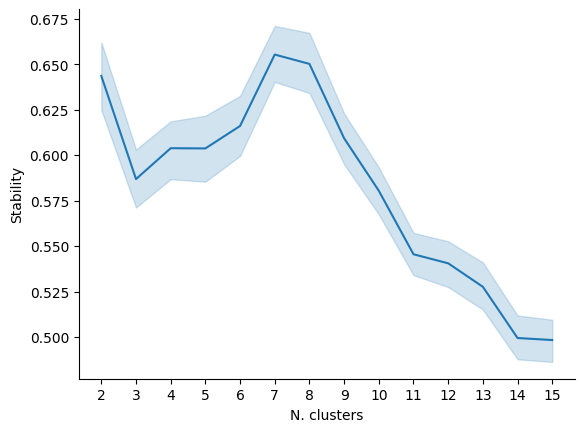

In [ ]:
cc.pl.autok_stability(autok)

In [ ]:
adata.obs['cluster_cellcharter'] = autok.predict(adata,k=7, use_rep='X_cellcharter')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


### Save Dataset

In [ ]:
adata.write_h5ad('data/legnini/adata_legnini_IS.h5ad')

## Dual Local (GCN) + Global (Transformer)

### Train

In [6]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assign

In [7]:
cfg_path = 'config_files/legnini_23/InterScale_Legnini_Nrec_Modular.yaml'
model_type = 'CombinedModel'

In [8]:
cfg = load_config(cfg_path)
print(cfg)
adata = sc.read_h5ad(cfg.dataset.h5ad_data)

dataset:
  batch_size: 3
  description: 
  group_label: condition
  h5ad_data: /beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/InterScale_reproducibility/data/legnini/adata_legnini_IS.h5ad
  layer_key: log1p_norm
  name: legnini23nrec
  num_classes: -1
  num_features: -1
  pct_mask_nodes: 0.3
  prediction_level: node
  prediction_obs: None
  prediction_task: regression
  sample_key: ['sample']
  segmentation_robustness: [0.2, 0.5]
  spatial_neigbors_kwargs:
    coord_type: generic
    library_key: sample
    n_neighs: 6
    radius: 200
  split_key: split
  stratify_group: None
  test_size: 0.1
  train_size: 0.7
  val_size: 0.2
model:
  decoder:
    dropout_decoder: 0.1
    dual_decoder: True
    hidden_dims: [256, 128]
    type: linear
  global_component:
    latent_obsm_key: None
    name: self-attn-transformer
    parameters:
      activation_func: relu
      dim_feedforward: 256
      dropout_global: 0.1
      long_range_attention: False
      max_seq_len: 4299
    

In [9]:
cfg = load_config(cfg_path)
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


Nr. of zero expression cells: 0


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  17   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                sample_key_0 State Registry                
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [10]:
adata.obsp['adjacency_matrix_connectivities']=adata.obsp['spatial_connectivities']

In [11]:
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)


dm = GraphAnnDataModule(datas=pyg_data_list, 
						num_workers=10,
						batch_size=int(cfg.dataset.batch_size), 
						pct_mask_nodes=cfg.dataset.pct_mask_nodes,
						learning_type="node")


Split key split already exists in adata.obs


In [12]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [13]:

model = interscale.model.CombinedModel(
	adata,
	cfg = cfg
)


model.train(max_epochs = 40, 
           datamodule = dm,
           early_stopping = True,
		   enable_progress_bar=True,
           wandb_use = False)

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
[rank: 0] Seed set to 44


Steps per epoch 6
cross-cell per gene correlation metrics


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type                           | Params | Mode 
-------------------------------------------------------------------------
0 | module        | DualDecoderCombinedModuleClass | 51.2 K | train
1 | loss          | SCELoss                        | 0      | train
2 | train_metrics | MetricCollection               | 0      | train
3 | valid_metrics | MetricCollection               | 0      | train
4 | test_metrics  | MetricCollection               | 0      | train
-------------------------------------------------------------------------
51.2 K    Trainable params
0         Non-trainable params
51.2 K    Total params
0.205     Total estimated model params size (MB)
63        Modules in train mode
0         Modules in eval mode
SLURM auto-requeueing enabled. Setting signal handlers.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Testing: |          | 0/? [00:00<?, ?it/s]

on_test_epoch_end 35


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  test_cosine_similarity   │    0.7883150577545166     │
│     test_global_loss      │    0.01776202581822872    │
│      test_local_loss      │    0.02021879330277443    │
│         test_loss         │    0.01899041049182415    │
│         test_mse          │    0.8556995391845703     │
│     test_pearson_corr     │    0.04342642053961754    │
│          test_r2          │    -1.3783880472183228    │
└───────────────────────────┴───────────────────────────┘


Early stopping triggered at epoch 34
Best val_loss: 0.0196
Model checkpoint will be saved in:  /beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/InterScale_reproducibility/model/dual_legnini23nrec_regr_node_44_GCN_self-attn-transformer_model.ckpt


### Evaluate

In [26]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [27]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)

Nr. of zero expression cells: 0


In [28]:
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  17   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                sample_key_0 State Registry                
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [29]:
model= interscale.model.CombinedModel(
	adata,
	cfg = cfg
)


model=model.load(adata=adata,cfg=cfg,dir_path='model',global_component=True,local_component=True)

Loading model from model/dual_legnini23nrec_regr_node_44_GCN_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [30]:
set_full_reproducibility(42)
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


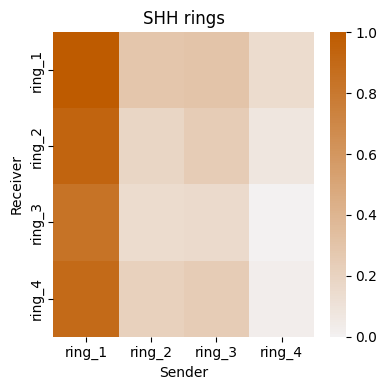

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for ix,c in enumerate(['SHH_cats']):

	attn_mxs = {}


	for sample in np.unique(result.obs['sample']):

		mask = result.obs['sample'] == sample

		attn_matrix = result.obsm['_attn_matrix'][mask]
		labels = result.obs[c][mask].values
		

		if attn_matrix.dtype == 'O':

			df_temp = pd.DataFrame(attn_matrix)
			df_numeric = df_temp.apply(pd.to_numeric, errors='coerce')

			valid_cols = ~df_numeric.isna().all(axis=0)
			attn_matrix_cleaned = df_numeric.loc[:, valid_cols].values

			del df_temp, df_numeric
		else:
			attn_matrix_cleaned = np.array(attn_matrix, dtype=float)
		np.fill_diagonal(attn_matrix_cleaned,0)

		aggregated_matrix_df = aggregate_attention_matrix_optimized(attn_matrix_cleaned, labels)
		attn_mxs[sample] = aggregated_matrix_df
		

		del attn_matrix, attn_matrix_cleaned


	average_attention_matrix = aggregate_attention_matrices(attn_mxs)


	if average_attention_matrix is not None:
		min_val = average_attention_matrix.min().min()
		max_val = average_attention_matrix.max().max()
		if max_val != min_val:
			norm_matrix = (average_attention_matrix - min_val) / (max_val - min_val)
		else:
			norm_matrix = average_attention_matrix

		clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)
	average_attention_matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

	clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(clean_matrix, cmap=map,center=0)
	plt.title(f'SHH rings')
	plt.xlabel('Sender')
	plt.ylabel('Receiver')


	clean_matrix.to_csv(f'results/legnini23_DinterscaleGCN_shhcats.csv')



plt.tight_layout()

## PCA + Global (Transformer)

### Train

In [8]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assign

In [9]:
cfg_path = 'config_files/legnini_23//InterScale_Legnini_Nrec_globalPCA.yaml'
model_type = 'GlobalModel'

In [10]:
cfg = load_config(cfg_path)
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


Nr. of zero expression cells: 0


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  17   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                sample_key_0 State Registry                
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [11]:
adata.obsp['adjacency_matrix_connectivities']=adata.obsp['spatial_connectivities']

In [12]:
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)


dm = GraphAnnDataModule(datas=pyg_data_list, 
						num_workers=10,
						batch_size=int(cfg.dataset.batch_size), 
						pct_mask_nodes=cfg.dataset.pct_mask_nodes,
						learning_type="node")


Split key split already exists in adata.obs


In [13]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [14]:

model = interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model.train(max_epochs = 40, 
           datamodule = dm,
           early_stopping = True,
		   enable_progress_bar=True,
           wandb_use = False)

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
[rank: 0] Seed set to 44
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Steps per epoch 6
cross-cell per gene correlation metrics


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/InterScale_reproducibility/model exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type                       | Params | Mode 
---------------------------------------------------------------------
0 | module        | TransformerNodeEncoderHook | 20.8 K | train
1 | loss          | SCELoss                    | 0      | train
2 | train_metrics | MetricCollection           | 0      | train
3 | valid_metrics | MetricCollection           | 0      | train
4 | test_metrics  | MetricCollection           | 0      | train
---------------------------------------------------------------------
20.8 K    Trainable params
0         Non-trainable params
20.8 K    Total params
0.083     Total estimated model params size (MB)
43        Modules in train

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Testing: |          | 0/? [00:00<?, ?it/s]

on_test_epoch_end 29


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  test_cosine_similarity   │    0.8119708895683289     │
│         test_loss         │   0.014787190593779087    │
│         test_mse          │    0.7979685664176941     │
│     test_pearson_corr     │    0.04932200908660889    │
│          test_r2          │    -0.8771827220916748    │
└───────────────────────────┴───────────────────────────┘


Early stopping triggered at epoch 28
Best val_loss: 0.0191
Model checkpoint will be saved in:  model/legnini23nrecGPca_regr_node_44_self-attn-transformer_model.ckpt


### Evaluate

In [21]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [22]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)

Nr. of zero expression cells: 0


In [23]:
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  17   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                sample_key_0 State Registry                
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [24]:
model= interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model=model.load(adata=adata,cfg=cfg,dir_path='model',global_component=True,local_component=True)

Loading model from model/legnini23nrecGPca_regr_node_44_self-attn-transformer_model.pt


Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [25]:
set_full_reproducibility(42)
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


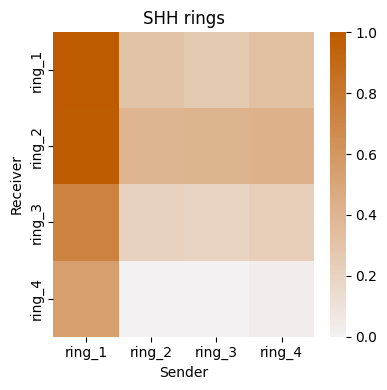

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for ix,c in enumerate(['SHH_cats']):

	attn_mxs = {}


	for sample in np.unique(result.obs['sample']):

		mask = result.obs['sample'] == sample

		attn_matrix = result.obsm['_attn_matrix'][mask]
		labels = result.obs[c][mask].values
		

		if attn_matrix.dtype == 'O':

			df_temp = pd.DataFrame(attn_matrix)
			df_numeric = df_temp.apply(pd.to_numeric, errors='coerce')

			valid_cols = ~df_numeric.isna().all(axis=0)
			attn_matrix_cleaned = df_numeric.loc[:, valid_cols].values

			del df_temp, df_numeric
		else:
			attn_matrix_cleaned = np.array(attn_matrix, dtype=float)
		np.fill_diagonal(attn_matrix_cleaned,0)

		aggregated_matrix_df = aggregate_attention_matrix_optimized(attn_matrix_cleaned, labels)
		attn_mxs[sample] = aggregated_matrix_df
		

		del attn_matrix, attn_matrix_cleaned


	average_attention_matrix = aggregate_attention_matrices(attn_mxs)


	if average_attention_matrix is not None:
		min_val = average_attention_matrix.min().min()
		max_val = average_attention_matrix.max().max()
		if max_val != min_val:
			norm_matrix = (average_attention_matrix - min_val) / (max_val - min_val)
		else:
			norm_matrix = average_attention_matrix

		clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)
	average_attention_matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

	clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(clean_matrix, cmap=map,center=0)
	plt.title(f'SHH rings')
	plt.xlabel('Sender')
	plt.ylabel('Receiver')


	clean_matrix.to_csv(f'results/legnini23_GinterscalePCA_shhcats.csv')



plt.tight_layout()

## SCVI latent + Global (Transformer)

### Train

In [27]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [28]:
cfg_path = 'config_files/legnini_23//InterScale_Legnini_Nrec_globalSCVI.yaml'
model_type = 'GlobalModel'

In [29]:
cfg = load_config(cfg_path)
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


Nr. of zero expression cells: 0


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  17   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                sample_key_0 State Registry                
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [30]:
adata.obsp['adjacency_matrix_connectivities']=adata.obsp['spatial_connectivities']

In [31]:
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)


dm = GraphAnnDataModule(datas=pyg_data_list, 
						num_workers=10,
						batch_size=int(cfg.dataset.batch_size), 
						pct_mask_nodes=cfg.dataset.pct_mask_nodes,
						learning_type="node")


Split key split already exists in adata.obs


In [32]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:

model = interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model.train(max_epochs = 40, 
           datamodule = dm,
           early_stopping = True,
		   enable_progress_bar=True,
           wandb_use = False)

### Evaluate

In [34]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [35]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)

Nr. of zero expression cells: 0


In [36]:
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  17   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                sample_key_0 State Registry                
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [37]:
model= interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model=model.load(adata=adata,cfg=cfg,dir_path='model',global_component=True,local_component=True)

Loading model from model/legnini23nrecGSCVI_regr_node_44_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [38]:
set_full_reproducibility(42)
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/GT-long-range-niches/src/InterScale/model/GlobalModel.py:105: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embedding = torch.tensor(embedding, dtype=torch.float32, device=batch.x.device)


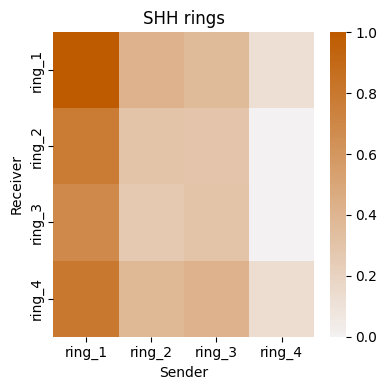

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for ix,c in enumerate(['SHH_cats']):

	attn_mxs = {}


	for sample in np.unique(result.obs['sample']):

		mask = result.obs['sample'] == sample

		attn_matrix = result.obsm['_attn_matrix'][mask]
		labels = result.obs[c][mask].values
		

		if attn_matrix.dtype == 'O':

			df_temp = pd.DataFrame(attn_matrix)
			df_numeric = df_temp.apply(pd.to_numeric, errors='coerce')

			valid_cols = ~df_numeric.isna().all(axis=0)
			attn_matrix_cleaned = df_numeric.loc[:, valid_cols].values

			del df_temp, df_numeric
		else:
			attn_matrix_cleaned = np.array(attn_matrix, dtype=float)
		np.fill_diagonal(attn_matrix_cleaned,0)

		aggregated_matrix_df = aggregate_attention_matrix_optimized(attn_matrix_cleaned, labels)
		attn_mxs[sample] = aggregated_matrix_df
		

		del attn_matrix, attn_matrix_cleaned


	average_attention_matrix = aggregate_attention_matrices(attn_mxs)


	if average_attention_matrix is not None:
		min_val = average_attention_matrix.min().min()
		max_val = average_attention_matrix.max().max()
		if max_val != min_val:
			norm_matrix = (average_attention_matrix - min_val) / (max_val - min_val)
		else:
			norm_matrix = average_attention_matrix

		clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)
	average_attention_matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

	clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(clean_matrix, cmap=map,center=0)
	plt.title(f'SHH rings')
	plt.xlabel('Sender')
	plt.ylabel('Receiver')


	clean_matrix.to_csv(f'results/legnini23_GinterscaleSCVI_shhcats.csv')



plt.tight_layout()

## CellCharter latent + Global (Transformer)

### Train

In [41]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [42]:
cfg_path = 'config_files/legnini_23//InterScale_Legnini_Nrec_globalCellCharter.yaml'
model_type = 'GlobalModel'

In [43]:
cfg = load_config(cfg_path)
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


Nr. of zero expression cells: 0


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  17   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                sample_key_0 State Registry                
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [44]:
adata.obsp['adjacency_matrix_connectivities']=adata.obsp['spatial_connectivities']

In [45]:
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)


dm = GraphAnnDataModule(datas=pyg_data_list, 
						num_workers=10,
						batch_size=int(cfg.dataset.batch_size), 
						pct_mask_nodes=cfg.dataset.pct_mask_nodes,
						learning_type="node")


Split key split already exists in adata.obs


In [46]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:

model = interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model.train(max_epochs = 40, 
           datamodule = dm,
           early_stopping = True,
		   enable_progress_bar=True,
           wandb_use = False)

### Evaluate

In [47]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [48]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)

Nr. of zero expression cells: 0


In [49]:
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  17   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                sample_key_0 State Registry                
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [51]:
model= interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model=model.load(adata=adata,cfg=cfg,dir_path='model',global_component=True,local_component=True)

Loading model from model/legnini23nrecGCc_regr_node_44_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


In [52]:
set_full_reproducibility(42)
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/GT-long-range-niches/src/InterScale/model/GlobalModel.py:105: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embedding = torch.tensor(embedding, dtype=torch.float32, device=batch.x.device)


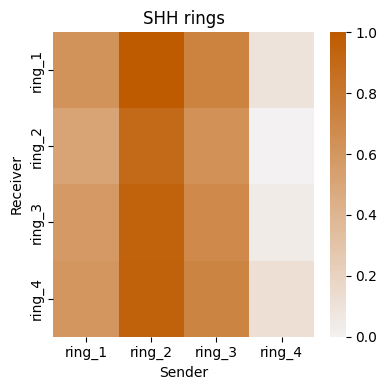

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for ix,c in enumerate(['SHH_cats']):

	attn_mxs = {}


	for sample in np.unique(result.obs['sample']):

		mask = result.obs['sample'] == sample

		attn_matrix = result.obsm['_attn_matrix'][mask]
		labels = result.obs[c][mask].values
		

		if attn_matrix.dtype == 'O':

			df_temp = pd.DataFrame(attn_matrix)
			df_numeric = df_temp.apply(pd.to_numeric, errors='coerce')

			valid_cols = ~df_numeric.isna().all(axis=0)
			attn_matrix_cleaned = df_numeric.loc[:, valid_cols].values

			del df_temp, df_numeric
		else:
			attn_matrix_cleaned = np.array(attn_matrix, dtype=float)
		np.fill_diagonal(attn_matrix_cleaned,0)

		aggregated_matrix_df = aggregate_attention_matrix_optimized(attn_matrix_cleaned, labels)
		attn_mxs[sample] = aggregated_matrix_df
		

		del attn_matrix, attn_matrix_cleaned


	average_attention_matrix = aggregate_attention_matrices(attn_mxs)


	if average_attention_matrix is not None:
		min_val = average_attention_matrix.min().min()
		max_val = average_attention_matrix.max().max()
		if max_val != min_val:
			norm_matrix = (average_attention_matrix - min_val) / (max_val - min_val)
		else:
			norm_matrix = average_attention_matrix

		clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)
	average_attention_matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

	clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(clean_matrix, cmap=map,center=0)
	plt.title(f'SHH rings')
	plt.xlabel('Sender')
	plt.ylabel('Receiver')


	clean_matrix.to_csv(f'results/legnini23_GinterscaleCellCharter_shhcats.csv')



plt.tight_layout()

# Steamboat

## Setup

In [1]:
import os
INTERSCALE_DIR = '/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/InterScale_reproducibility'
print(INTERSCALE_DIR)
os.chdir(INTERSCALE_DIR)

/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/InterScale_reproducibility


In [2]:
import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.

In [4]:
import torch
import scanpy as sc
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append("sftw/Steamboat")
import steamboat as sf # "sf" = "Steamboat Factorization"
import steamboat.tools


## Prepare data

In [5]:
adata=sc.read_h5ad('data/legnini/legnini23.h5ad')
adata.obs['fov']=adata.obs['sample']

In [6]:
adatas=[]

for i in adata.obs['fov'].unique():
    temp = adata[adata.obs['fov'] == i].copy()
    if temp.shape[0] < 100:
        continue
    adatas.append(temp)
    adatas[-1].obs['global'] = 0

In [7]:
adatas = sf.prep_adatas(adatas, norm=True, log1p=True, scale=False, renorm=False)

100%|██████████| 17/17 [00:00<00:00, 59.43it/s]


In [8]:
dataset = sf.make_dataset(adatas,regional_obs=['global'])

Using ['global'] as regional annotations.


100%|██████████| 17/17 [00:00<00:00, 181.91it/s]


## Prepare Model

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
n_heads = 25

sf.set_random_seed(0)
model = sf.Steamboat(adatas[0].var_names.tolist(), n_heads=n_heads, n_scales=3)
model = model.to(device)

    
model=model.to(device)


In [ ]:
model.fit(dataset, entry_masking_rate=0.1, feature_masking_rate=0.1,
          max_epoch=10000, 
          loss_fun=torch.nn.MSELoss(reduction='sum'),
          opt=torch.optim.Adam, opt_args=dict(lr=0.001), stop_eps=1e-3, report_per=200, stop_tol=200, device=device)

In [ ]:
torch.save(model.state_dict(), 'model/steamboat_legnini_model.pth')

## Evaluate

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
n_heads = 25

sf.set_random_seed(0)
model = sf.Steamboat(adatas[0].var_names.tolist(), n_heads=n_heads, n_scales=3)
model = model.to(device)

    
model=model.to(device)


In [11]:
model.load_state_dict(torch.load('model/steamboat_legnini_model.pth', map_location='cpu'))

<All keys matched successfully>

In [12]:
all_adata=sc.read_h5ad('data/legnini/legnini23.h5ad')
all_adata.obs['fov']=all_adata.obs['sample']

In [13]:
sf.tools.calc_obs(adatas, dataset, model, get_recon=True,device=device)
sf.tools.gather_obs(all_adata, adatas)

100%|██████████| 17/17 [00:00<00:00, 21.11it/s]


AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', 'fov'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial', 'q', 'local_k', 'ego_attn', 'local_attn', 'global_attn', 'attn', 'global_k_0', 'X_recon'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

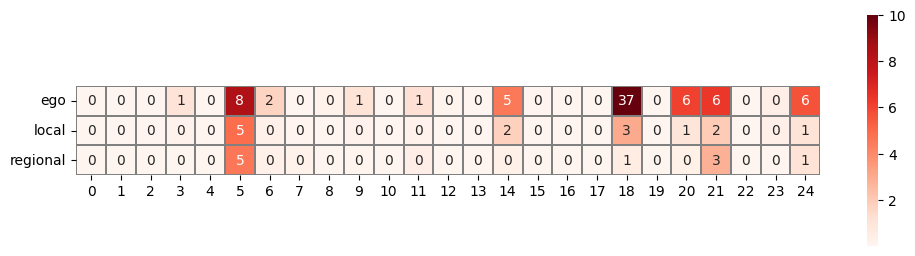

In [14]:
head_weights = sf.tools.calc_head_weights(adatas, model)
sf.tools.plot_head_weights(head_weights,figsize=(12,3))

In [15]:
result=all_adata.copy()

In [17]:
metaclusters=pd.read_csv('data/legnini/adata_legnini_Cellclusters.csv')[['Cell','SHH_zone','SHH_cats','cluster_cellcharter']]

In [18]:
result.obs=result.obs.merge(metaclusters,left_on='Cell', right_on='Cell', how='left', suffixes=('', '_true'))

In [19]:
result.obsm['global_attn_0'] =result.obsm['global_attn']

### Local attention

In [20]:
d_k=result.obsm['q'].shape[-1]
logits = np.dot(result.obsm['q'], result.obsm['local_k'].T)
scaled_logits = logits / np.sqrt(d_k)

e_x = np.exp(scaled_logits - np.max(scaled_logits, axis=-1, keepdims=True))
attn_matrix = e_x / e_x.sum(axis=-1, keepdims=True)

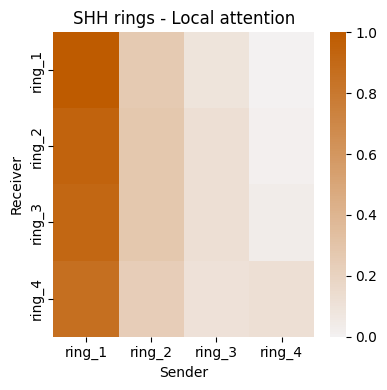

In [22]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
#ax=ax.flatten()
name_map={'leiden_pca':'leiden','SHH_zone':'shhzone','SHH_cats':'shhcats','cluster_cellcharter':'cellcharter'}
for i,col in enumerate(['SHH_cats']):
	df = pd.DataFrame(attn_matrix, index=result.obs[col], columns=result.obs[col])
	row_grouped = df.groupby(level=0).mean()
	cluster_attn_df = row_grouped.groupby(level=0, axis=1).mean()
	#df_scaled = cluster_attn_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
	df_norm = (cluster_attn_df - cluster_attn_df.min().min()) / (cluster_attn_df.max().max() - cluster_attn_df.min().min())
	df_scaled = df_norm 
	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(df_scaled,cmap=map, center=0)

	plt.title(f'SHH rings - Local attention')
	plt.xlabel('Sender')
	plt.ylabel('Receiver')
	df_scaled.to_csv(f'results/legnini23_LSteamboat_{name_map[col]}.csv')

plt.tight_layout()

### Global attention

In [23]:
d_k=result.obsm['q'].shape[-1]
logits = np.dot(result.obsm['q'], result.obsm['global_k_0'].T)
scaled_logits = logits / np.sqrt(d_k)

e_x = np.exp(scaled_logits - np.max(scaled_logits, axis=-1, keepdims=True))
attn_matrix = e_x / e_x.sum(axis=-1, keepdims=True)

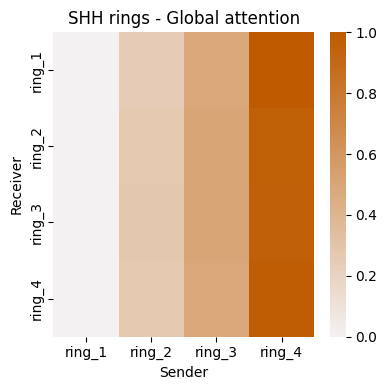

In [24]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
#ax=ax.flatten()
name_map={'leiden_pca':'leiden','SHH_zone':'shhzone','SHH_cats':'shhcats','cluster_cellcharter':'cellcharter'}
for i,col in enumerate(['SHH_cats']):
	df = pd.DataFrame(attn_matrix, index=result.obs[col], columns=result.obs[col])
	row_grouped = df.groupby(level=0).mean()
	cluster_attn_df = row_grouped.groupby(level=0, axis=1).mean()
	#df_scaled = cluster_attn_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
	df_norm = (cluster_attn_df - cluster_attn_df.min().min()) / (cluster_attn_df.max().max() - cluster_attn_df.min().min())
	df_scaled = df_norm 
	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(df_scaled,cmap=map, center=0)

	plt.title(f'SHH rings - Global attention')
	plt.xlabel('Sender')
	plt.ylabel('Receiver')
	df_scaled.to_csv(f'results/legnini23_GSteamboat_{name_map[col]}.csv')

plt.tight_layout()

# Compare

In [55]:
from scipy.stats import pearsonr

In [56]:
def compute_approach_correlation(dfs_dict):
    """
    Calculate Pearson correlation between different attention matrices.
    
    Parameters:
    -----------
    dfs_dict : dict
        Dictionary {approach_name: dataframe [n_cluster x n_cluster]}
    """
    approach_names = list(dfs_dict.keys())
    n_approaches = len(approach_names)
    
    # Initialize an empty matrix for correlations
    corr_matrix = pd.DataFrame(np.zeros((n_approaches, n_approaches)), 
                               index=approach_names, 
                               columns=approach_names)
    
    # Flatten matrices and calculate Pearson
    for i, name1 in enumerate(approach_names):
        for j, name2 in enumerate(approach_names):
            # Flatten the DataFrames to 1D arrays
            vec1 = dfs_dict[name1].values.flatten()
            vec2 = dfs_dict[name2].values.flatten()
            
            # Calculate correlation coefficient
            corr, _ = pearsonr(vec1, vec2)
            corr_matrix.loc[name1, name2] = corr
            
    return corr_matrix

def reset_diagonal_to_zero(dfs_dict):
    """
    Set the diagonal of all attention DataFrames to zero.
    
    Parameters:
    -----------
    dfs_dict : dict
        Dictionary {approach_name: dataframe [n_cluster x n_cluster]}
    """
    for name, df in dfs_dict.items():
        # Using numpy.fill_diagonal is the most efficient way to modify the diagonal in-place
        # We access the underlying values of the DataFrame
        np.fill_diagonal(df.values, 0)
        
        # English comment: Optional - ensuring the DataFrame is returned to a consistent state
        # though np.fill_diagonal works in-place on the underlying numpy array.
        
    print("Diagonal values set to 0 for all dataframes.")

In [57]:
models=["amici","DinterscaleGCN","GinterscalePCA","GinterscaleSCVI","GinterscaleCellCharter","GSteamboat","LSteamboat"]
models_name=["Amici","Interscale Dual - GCN","Interscale Global - PCA","Interscale Global - SCVI","Interscale Global - CellCharter","Steamboat Global","Steamboat Local"]

dfs_dict_name = {}
for ix,model in enumerate(models):
	dfs_dict_name[models[ix]]=models_name[ix]

dfs_dict_name

{'amici': 'Amici',
 'DinterscaleGCN': 'Interscale Dual - GCN',
 'GinterscalePCA': 'Interscale Global - PCA',
 'GinterscaleSCVI': 'Interscale Global - SCVI',
 'GinterscaleCellCharter': 'Interscale Global - CellCharter',
 'GSteamboat': 'Steamboat Global',
 'LSteamboat': 'Steamboat Local'}

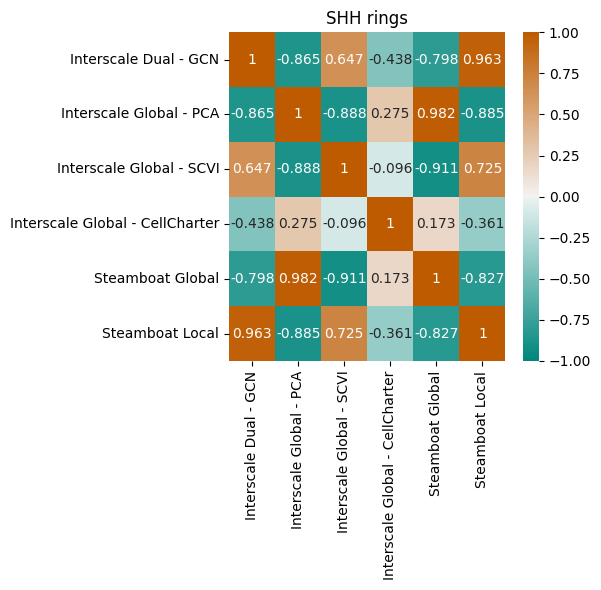

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

#for ix,c in enumerate(['leiden','shhzone','shhcats','cellcharter']):
for ix,c in enumerate(['shhcats']):
	dfs_dict = {}
	for jx,a in enumerate(["DinterscaleGCN","GinterscalePCA","GinterscaleSCVI","GinterscaleCellCharter","GSteamboat","LSteamboat"]):
		d=pd.read_csv(f'results/legnini23_{a}_{c}.csv',index_col=0)
		dfs_dict[dfs_dict_name[a]]=d
	#reset_diagonal_to_zero(dfs_dict)
	corr_matrix=compute_approach_correlation(dfs_dict)
	corr_matrix=corr_matrix.round(3)
	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(corr_matrix, annot=True, cmap=map, vmin=-1, vmax=1,fmt='.3g')
	plt.title(f"SHH rings")

plt.tight_layout()

#plt.savefig('INTERACTION/Benchmark/legnini23_Correlation_attention_approaches_shhcats.png',dpi=300)

# Amici

## Setup

In [2]:
import os
INTERSCALE_DIR = '/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/InterScale_reproducibility'
print(INTERSCALE_DIR)
os.chdir(INTERSCALE_DIR)

/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/InterScale_reproducibility


In [3]:
import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.

In [4]:
import torch
import scanpy as sc
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import seaborn as sns
import matplotlib.pyplot as plt

from amici import AMICI
from amici.callbacks import AttentionPenaltyMonitor
from amici.interpretation import (
    AMICICounterfactualAttentionModule,
    AMICIAttentionModule,
    AMICIAblationModule,
)

## Prepare data

In [6]:
adata=sc.read_h5ad('data/legnini/legnini23.h5ad')


In [7]:
metaclusters=pd.read_csv('data/legnini/adata_legnini_Cellclusters.csv')[['Cell','SHH_zone','SHH_cats','cluster_cellcharter']]


In [8]:
adata.obs=adata.obs.merge(metaclusters,left_on='Cell', right_on='Cell', how='left', suffixes=('', '_true'))

In [9]:
adata.obs_names = adata.obs_names.astype(str)
adata=adata[adata.obs['cluster_cellcharter'].notna()]
adata.obs['annotation']=adata.obs['cluster_cellcharter'].astype(str)

## Setup model

In [10]:
# Set up the seed for reproducibility
seed = 42
pl.seed_everything(seed)

penalty_schedule_params = {
    "start_val": 1e-6,
    "end_val": 1e-3,
    "epoch_start": 10,
    "epoch_end": 30,
    "flavor": "linear",
}
model_params = {
    "n_heads": 8,
    "n_query_dim": 128,
    "n_head_size": 32,
    "n_nn_embed": 256,
    "n_nn_embed_hidden": 512,
    "attention_dummy_score": 3.0,
    "neighbor_dropout": 0.1,
    "attention_penalty_coef": penalty_schedule_params[
        "start_val"
    ],
    "value_l1_penalty_coef": 1e-5,
}
exp_params = {
    "lr": 1e-3,
    "epochs": 400,
    "batch_size": 512,
    "early_stopping": True,
    "early_stopping_monitor": "elbo_validation",
    "early_stopping_patience": 20,
    "learning_rate_monitor": True,
    "n_neighbors": 50,
}

[rank: 0] Seed set to 42


In [11]:
AMICI.setup_anndata(
    adata,
    labels_key="annotation",
    coord_obsm_key="spatial",
    n_neighbors=exp_params["n_neighbors"],
)
model = AMICI(adata, **model_params)

INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


In [ ]:
model_path = os.path.join(
    "model",
    f"amici_legnini_{seed}_shhcats_params",
)

plan_kwargs = {}
if "lr" in exp_params:
    plan_kwargs["lr"] = exp_params["lr"]

### Train

In [ ]:
model.train(
    max_epochs=int(exp_params.get("epochs")),
    batch_size=int(exp_params.get("batch_size")),
    plan_kwargs=plan_kwargs,
    early_stopping=exp_params.get("early_stopping"),
    early_stopping_monitor=exp_params.get("early_stopping_monitor"),
    early_stopping_patience=exp_params.get("early_stopping_patience"),
    check_val_every_n_epoch=1,
    callbacks=[
        AttentionPenaltyMonitor(
            **penalty_schedule_params
        ),
    ],
)

In [ ]:
model.save(model_path, overwrite=True)

### Evaluate

In [18]:
prefix='shhcats'
seed=42
model_path = os.path.join(
    "model",
    f"amici_legnini_{seed}_{prefix}_params",
)
adata.obs['annotation']=adata.obs['SHH_cats'].astype(str)

In [20]:
model.load(model_path, adata)

INFO     File model/amici_legnini_42_shhcats_params/model.pt already downloaded                                    


Training status: Trained

In [ ]:

adata_residuals=model.get_neighbor_ablation_scores(
        adata=adata,
        compute_z_value=True,
    )

INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


In [ ]:
adata_residuals.save_object(f'data/legnini/legnini_{prefix}_residuals_amici.pkl')

AMICIAblationModule(_adata=AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', 'leiden', 'SHH_zone', 'SHH_cats', 'cluster_cellcharter', 'annotation', '_scvi_labels'
    var: 'gene_ids', 'feature_types'
    uns: 'n_neighbors', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', '_nn_idx', '_nn_dist'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', _ablation_scores_df=     index  5.0_ablation  5.0_diff  5.0_z_value  5.0_nl10_pval  \
0        0  0.000000e+00  0.000000     0.000000       0.301030   
1        1  0.000000e+00  0.000000     0.000000       0.301030   
2        2  0.000000e+00  0.000000     0.000000       0.301030   
3        3  0.000000e+00  0.000000     0.000000       0.301030   
4        4  0.000000e+00  0.000000     0.000000       0.301030   
..     ...           ...       ...          ...            ...   
611     83  3.060583e-02 -0.000912    -0.132078       0.257637   
612     84  

In [22]:
ablation_residuals=AMICIAblationModule.load_object(f'data/legnini/legnini_{prefix}_residuals_amici.pkl')